In [24]:
import pandas as pd
import matplotlib.pyplot as plt
from tslearn.utils import to_time_series_dataset
from yellowbrick.cluster import KElbowVisualizer
from tslearn.utils import to_sklearn_dataset
from tslearn.clustering import TimeSeriesKMeans

In [2]:
df = pd.read_csv('../../data/raw/plant_ids.csv')

In [3]:
df_orders = pd.read_csv('../../data/processed/orders.csv')


In [4]:
df.Date = pd.to_datetime(df.Date)

In [5]:
df = df.set_index('Date')

In [ ]:
def rolling_orders_6(x):
    """Check if average non-zero invoices in rolling windows exceeds threshold"""
    ts = x.set_index('Date').sort_index().Invoiced_Quantity
    # More efficient way to count non-zero values in each window
    return (ts > 0).rolling(6).sum().mean() > 2

In [18]:
def review_plant(plant_df):
    # Get customers meeting the condition
    condition1 = plant_df.groupby('customer_id').apply(rolling_orders_6)
    
    # Process Invoiced_Quantity
    invoices_grouped = plant_df.groupby('customer_id').apply(
        lambda x: x.set_index('Date').sort_index()['Invoiced_Quantity']
    )
    invoices = invoices_grouped.reset_index().drop_duplicates().set_index(
        invoices_grouped.index.names
    ).unstack(0)
    
    # Filter to customers meeting condition1
    selection1 = invoices['Invoiced_Quantity'].T[condition1].T    
    # Further filter customers based on recent activity
    selection2 = selection1.T[selection1.tail(6).isna().sum() != 6].T
    (selection2.sum(axis=1)/plant_df.query('Monday_number==5').groupby(['Date']).Invoiced_Quantity.sum()).plot()
    plt.title('comparison with demand of customers who are delivered from unique plant')
    plt.show()
    return selection2

In [13]:
df = df.reset_index()

In [14]:
df.Date = df.Date.dt.tz_localize(None)

A


/var/folders/tj/c9x9f0j55b53skv8htzftqsh0000gn/T/ipykernel_25772/2842984362.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  condition1 = plant_df.groupby('customer_id').apply(rolling_orders_6)
/var/folders/tj/c9x9f0j55b53skv8htzftqsh0000gn/T/ipykernel_25772/2842984362.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  invoices_grouped = plant_df.groupby('customer_id').apply(


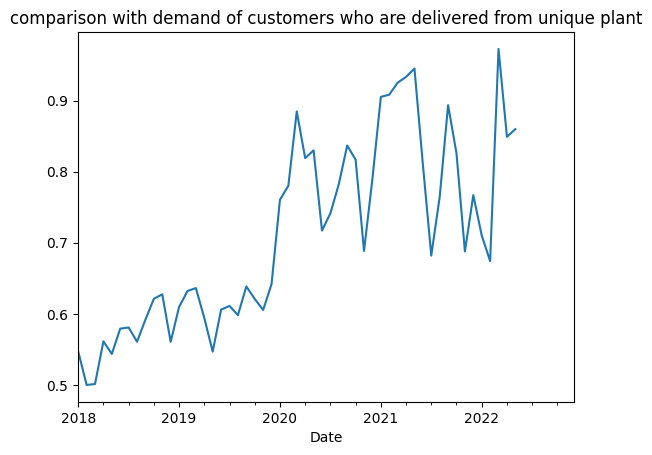

B


/var/folders/tj/c9x9f0j55b53skv8htzftqsh0000gn/T/ipykernel_25772/2842984362.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  condition1 = plant_df.groupby('customer_id').apply(rolling_orders_6)
/var/folders/tj/c9x9f0j55b53skv8htzftqsh0000gn/T/ipykernel_25772/2842984362.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  invoices_grouped = plant_df.groupby('customer_id').apply(


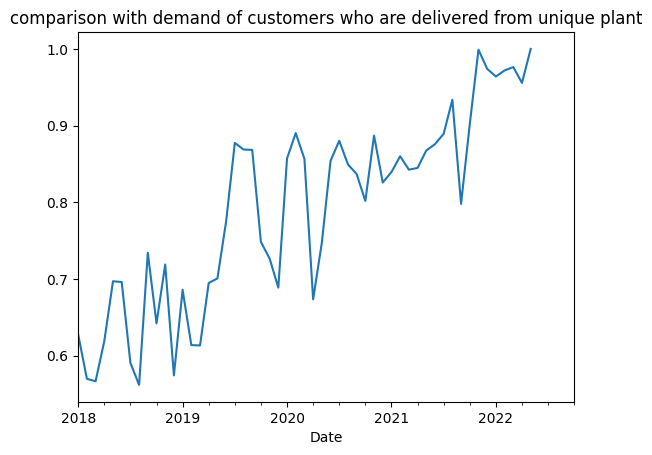

C


/var/folders/tj/c9x9f0j55b53skv8htzftqsh0000gn/T/ipykernel_25772/2842984362.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  condition1 = plant_df.groupby('customer_id').apply(rolling_orders_6)
/var/folders/tj/c9x9f0j55b53skv8htzftqsh0000gn/T/ipykernel_25772/2842984362.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  invoices_grouped = plant_df.groupby('customer_id').apply(


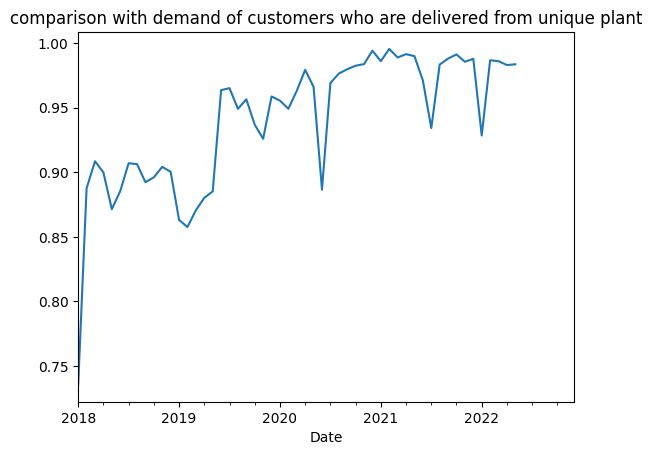

D


/var/folders/tj/c9x9f0j55b53skv8htzftqsh0000gn/T/ipykernel_25772/2842984362.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  condition1 = plant_df.groupby('customer_id').apply(rolling_orders_6)
/var/folders/tj/c9x9f0j55b53skv8htzftqsh0000gn/T/ipykernel_25772/2842984362.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  invoices_grouped = plant_df.groupby('customer_id').apply(


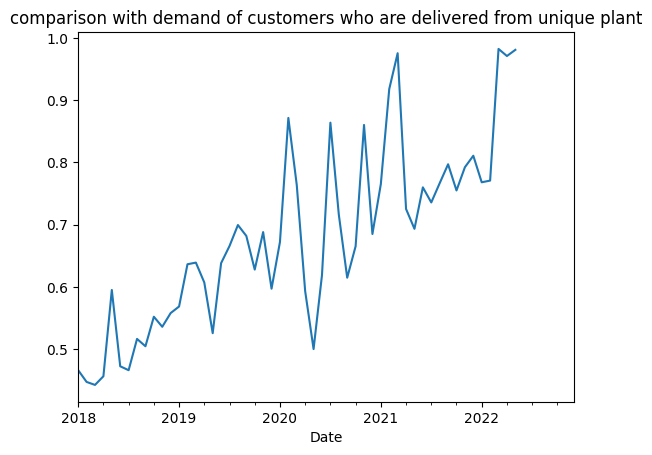

E


/var/folders/tj/c9x9f0j55b53skv8htzftqsh0000gn/T/ipykernel_25772/2842984362.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  condition1 = plant_df.groupby('customer_id').apply(rolling_orders_6)
/var/folders/tj/c9x9f0j55b53skv8htzftqsh0000gn/T/ipykernel_25772/2842984362.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  invoices_grouped = plant_df.groupby('customer_id').apply(


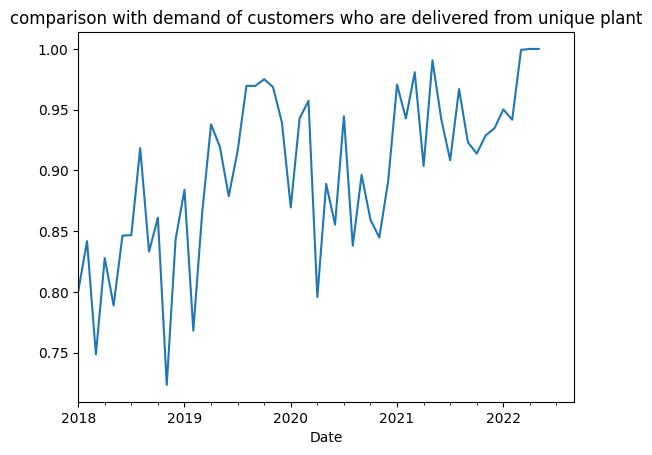

F


/var/folders/tj/c9x9f0j55b53skv8htzftqsh0000gn/T/ipykernel_25772/2842984362.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  condition1 = plant_df.groupby('customer_id').apply(rolling_orders_6)
/var/folders/tj/c9x9f0j55b53skv8htzftqsh0000gn/T/ipykernel_25772/2842984362.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  invoices_grouped = plant_df.groupby('customer_id').apply(


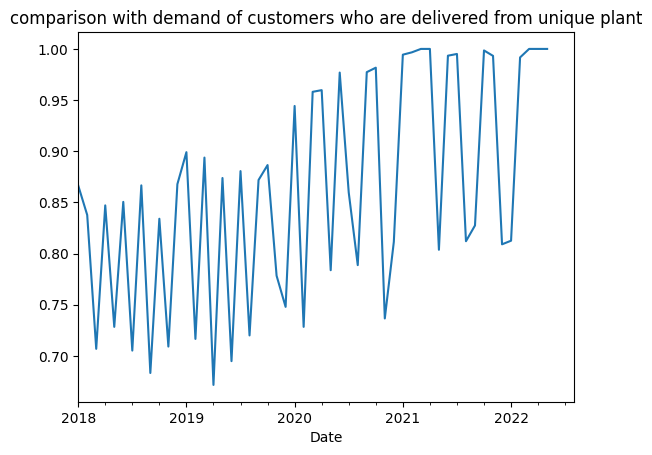

In [19]:
lsdf = dict()
for plant, pdf in df.groupby('Plant'):
    print(plant)
    sdf = review_plant(pdf)
    lsdf[plant] = sdf

# Clusters

In [23]:
formatted = dict()
for plant, sdf in lsdf.items():
    fs = to_time_series_dataset(sdf.T.fillna(0))
    formatted[plant] = fs

In [25]:
df.groupby('Plant').customer_id.nunique()

Plant
A    198
B    287
C    282
D    468
E    153
F    109
Name: customer_id, dtype: int64

In [ ]:
kms = dict()



Processing plant: A


/Users/eldi/Documents/Projects/Hierarchical-Time-Series/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/eldi/Documents/Projects/Hierarchical-Time-Series/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/eldi/Documents/Projects/Hierarchical-Time-Series/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/eldi/Documents/Projects/Hierarchical-Time-Series/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/eldi/Documents/Projects/Hierarchical-Time-Series/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 a

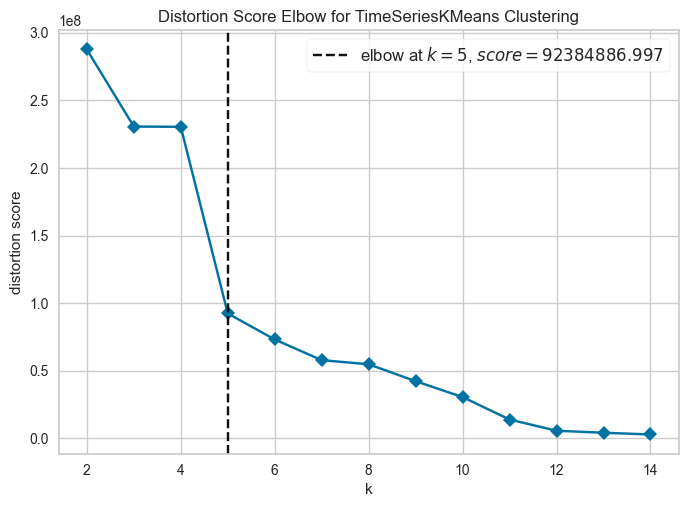

/Users/eldi/Documents/Projects/Hierarchical-Time-Series/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Processing plant: B


/Users/eldi/Documents/Projects/Hierarchical-Time-Series/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/eldi/Documents/Projects/Hierarchical-Time-Series/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/eldi/Documents/Projects/Hierarchical-Time-Series/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/eldi/Documents/Projects/Hierarchical-Time-Series/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/eldi/Documents/Projects/Hierarchical-Time-Series/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/eldi/Do

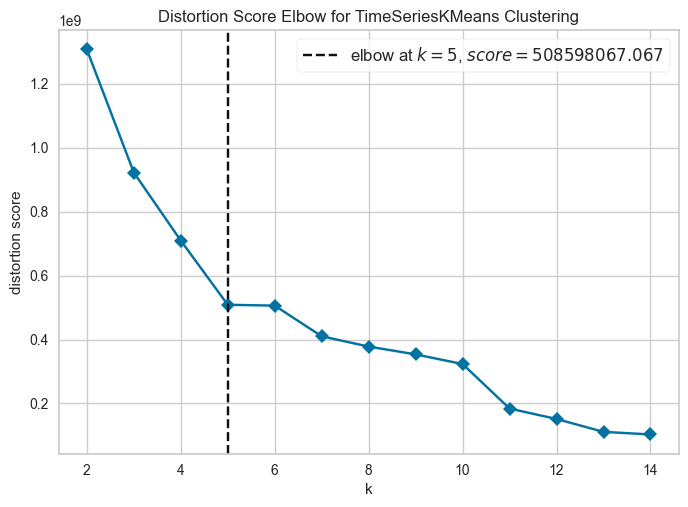

/Users/eldi/Documents/Projects/Hierarchical-Time-Series/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Processing plant: C


/Users/eldi/Documents/Projects/Hierarchical-Time-Series/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/eldi/Documents/Projects/Hierarchical-Time-Series/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/eldi/Documents/Projects/Hierarchical-Time-Series/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/eldi/Documents/Projects/Hierarchical-Time-Series/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/eldi/Documents/Projects/Hierarchical-Time-Series/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/eldi/Do

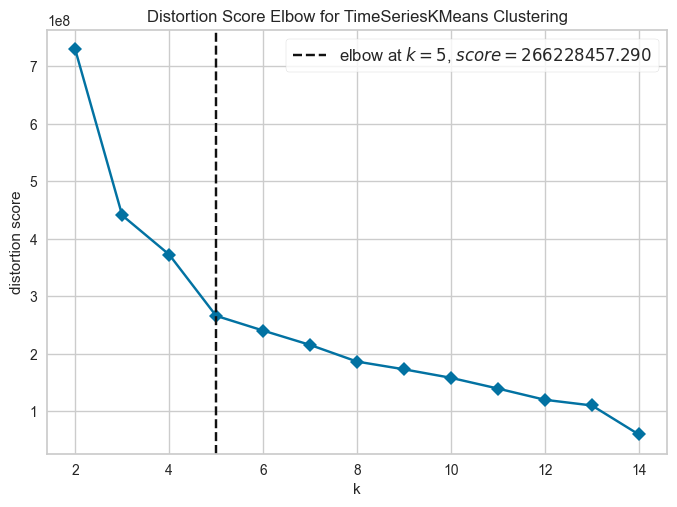

/Users/eldi/Documents/Projects/Hierarchical-Time-Series/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Processing plant: D


/Users/eldi/Documents/Projects/Hierarchical-Time-Series/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/eldi/Documents/Projects/Hierarchical-Time-Series/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/eldi/Documents/Projects/Hierarchical-Time-Series/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/eldi/Documents/Projects/Hierarchical-Time-Series/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/eldi/Documents/Projects/Hierarchical-Time-Series/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/eldi/Do

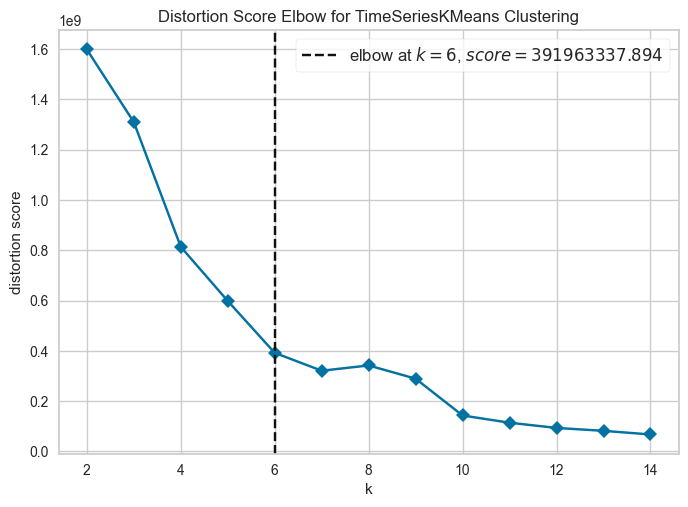

/Users/eldi/Documents/Projects/Hierarchical-Time-Series/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Processing plant: E


/Users/eldi/Documents/Projects/Hierarchical-Time-Series/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/eldi/Documents/Projects/Hierarchical-Time-Series/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/eldi/Documents/Projects/Hierarchical-Time-Series/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/eldi/Documents/Projects/Hierarchical-Time-Series/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/eldi/Documents/Projects/Hierarchical-Time-Series/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/eldi/Do

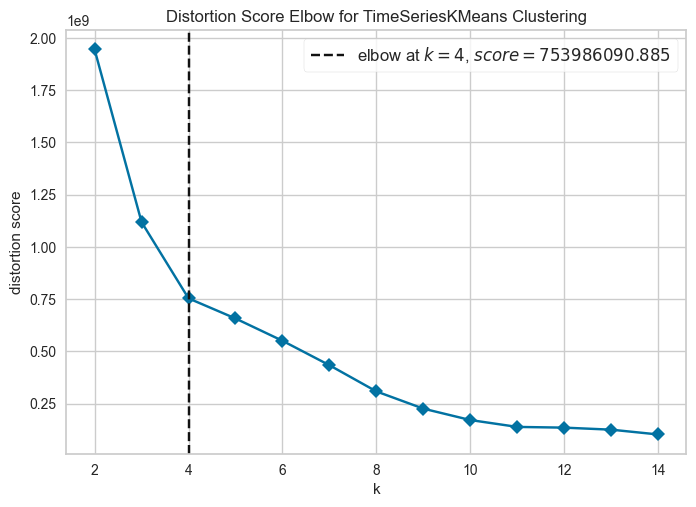

/Users/eldi/Documents/Projects/Hierarchical-Time-Series/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Processing plant: F


/Users/eldi/Documents/Projects/Hierarchical-Time-Series/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/eldi/Documents/Projects/Hierarchical-Time-Series/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/eldi/Documents/Projects/Hierarchical-Time-Series/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/eldi/Documents/Projects/Hierarchical-Time-Series/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/eldi/Documents/Projects/Hierarchical-Time-Series/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/eldi/Do

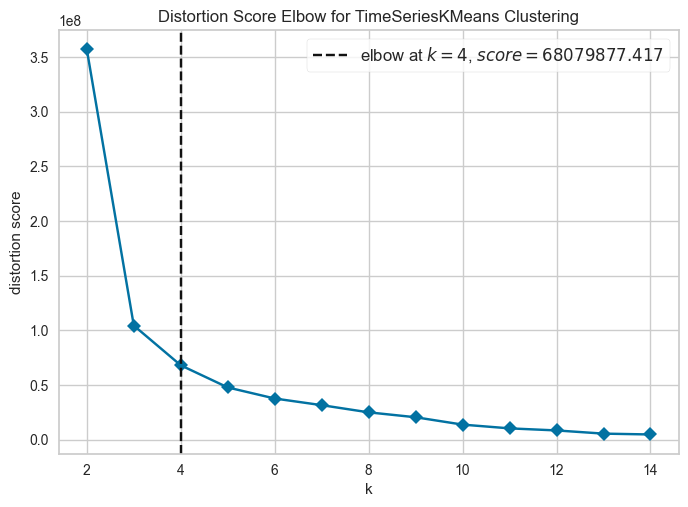

In [28]:
for plant, ts_data in formatted.items():
    print(f"Processing plant: {plant}")
    ts_data_sklearn = to_sklearn_dataset(ts_data)  # Convert to sklearn-compatible dataset
    model = TimeSeriesKMeans(metric="softdtw", random_state=42)
    visualizer = KElbowVisualizer(model, k=(2, 15), timings=False)
    visualizer.fit(ts_data_sklearn)
    visualizer.show()

In [29]:
cluster_number = {
    'A': 12,
    'B': 11,
    'C': 14,
    'D': 10,
    'E': 8,
    'F': 4
}

In [30]:
kms = dict()

for plant, fs in formatted.items():
    print(f"Processing plant: {plant}")
    ts_data_sklearn = to_sklearn_dataset(fs)  # Convert to sklearn-compatible dataset
    model = TimeSeriesKMeans(n_clusters=cluster_number[plant], metric="softdtw", random_state=42, verbose=1)
    model.fit(ts_data_sklearn)
    kms[plant] = model

Processing plant: A


/Users/eldi/Documents/Projects/Hierarchical-Time-Series/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


79100858652.316 --> 12486367569.326 --> 12502056177.624 --> 12516853842.975 --> 12531169607.473 --> 12533546804.723 --> 12540211813.398 --> 12540505192.986 --> 12535746836.906 --> 12538119460.445 --> 12532637097.071 --> 12534354469.999 --> 12528666638.329 --> 12535821843.634 --> 12536885365.728 --> 12535950068.659 --> 12529164707.304 --> 12540076971.669 --> 12547118303.465 --> 12546484022.834 --> 12545219419.986 --> 12538913929.522 --> 12540355717.186 --> 12541294469.619 --> 12544571863.511 --> 12541924771.051 --> 12544601928.341 --> 12545858097.899 --> 12547245045.854 --> 12545635073.305 --> 12546512183.509 --> 12545609986.624 --> 12552146980.177 --> 12550028160.149 --> 12550661103.419 --> 12550818326.400 --> 12551006400.602 --> 12551013167.369 --> 12551102067.121 --> 12551116199.387 --> 12551159561.362 --> 12551179998.313 --> 12551202876.521 --> 12551204444.889 --> 12551213219.962 --> 12551214475.324 --> 12551219264.024 --> 12551218993.174 --> 12551220921.671 --> 12551221135.268 --> 

/Users/eldi/Documents/Projects/Hierarchical-Time-Series/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


3606751494925.578 --> 1169480616187.934 --> 1169135908556.238 --> 1168834933312.505 --> 1168795547475.334 --> 1168689150960.345 --> 1168625653882.414 --> 1168551139998.344 --> 1168481002447.088 --> 1168404522540.274 --> 1168344646048.621 --> 1168279179540.362 --> 1168224709417.970 --> 1168160806811.115 --> 1168090453644.831 --> 1168020289637.039 --> 1168045787892.942 --> 1168044785959.911 --> 1168044238696.980 --> 1168043214757.474 --> 1168042810290.911 --> 1168042148445.788 --> 1168041866667.873 --> 1168041425470.173 --> 1168041252431.876 --> 1168040948495.375 --> 1168040855651.113 --> 1168040637339.766 --> 1168040602233.548 --> 1168040435003.053 --> 1168040438528.547 --> 1168040306111.444 --> 1168040331125.029 --> 1168040225830.788 --> 1168040260347.980 --> 1168040176430.329 --> 1168040214099.259 --> 1168040145974.000 --> 1168040184616.296 --> 1168040126685.798 --> 1168040167014.042 --> 1168040113544.731 --> 1168040157930.980 --> 1168040103954.515 --> 1168040154395.682 --> 1168040097

...

4277252807049.991 --> 1102125890161.091 --> 1102806246749.151 --> 1103350176586.509 --> 1103834365892.672 --> 1104106549183.351 --> 1104156872555.522 --> 1104064470816.449 --> 1103908936716.845 --> 1103674699742.437 --> 1103496272289.195 --> 1103482612150.713 --> 1103465403985.720 --> 1103456080481.229 --> 1103445998637.375 --> 1103441542934.505 --> 1103418200238.354 --> 1103429931195.517 --> 1103431004194.614 --> 1103428002306.431 --> 1103427928742.084 --> 1103428516847.276 --> 1103428097280.850 --> 1103428411552.217 --> 1103428190909.010 --> 1103428461257.486 --> 1103428318973.024 --> 1103428546737.120 --> 1103427691502.482 --> 1103428985908.592 --> 1103428324789.007 --> 1103428875811.806 --> 1103428504973.243 --> 1103428745887.187 --> 1103428591439.921 --> 1103428691858.528 --> 1103428604208.335 --> 1103428785018.734 --> 1103428550770.485 --> 1103428648612.226 --> 1103428561751.452 --> 1103428596364.684 --> 1103428566117.911 --> 1103428574793.564 --> 1103428567100.283 --> 1103428566

/Users/eldi/Documents/Projects/Hierarchical-Time-Series/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


42018414799760.305 --> 16985575809348.230 --> 16894566470207.334 --> 16888862014667.273 --> 16887105072491.717 --> 16886971358125.689 --> 16887219664410.980 --> 16887949733879.189 --> 16888178289416.277 --> 16888582712993.180 --> 16889253170633.564 --> 16890221098702.453 --> 16890703174192.760 --> 16891221536097.723 --> 16890862757829.094 --> 16890831660456.297 --> 16890810183094.541 --> 16890804615248.236 --> 16890810683386.746 --> 16890824056126.777 --> 16890890024228.551 --> 16891003599943.084 --> 16890972905858.131 --> 16890975839316.131 --> 16890973108701.430 --> 16890974770808.301 --> 16890974087744.756 --> 16890974457086.270 --> 16890974041682.480 --> 16890974246236.936 --> 16890974033476.395 --> 16890974139420.727 --> 16890973989738.129 --> 16890974077578.898 --> 16890973996241.898 --> 16890974045327.754 --> 16890974759665.916 --> 16890973932581.061 --> 16890974137753.186 --> 16890973952296.260 --> 16890974101105.311 --> 16890973961035.195 --> 16890974094445.773 --> 16890973885

/Users/eldi/Documents/Projects/Hierarchical-Time-Series/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


8886750716164.570 --> 810064618009.127 --> 813040592339.252 --> 814086746691.104 --> 814122502750.595 --> 814090812142.386 --> 814095927379.126 --> 813826239697.828 --> 813799854447.227 --> 813799659021.884 --> 813766747557.997 --> 813773453982.014 --> 813723319649.175 --> 813763543044.607 --> 813703585714.906 --> 813749068422.274 --> 813687206418.764 --> 813710447532.599 --> 813670099277.567 --> 813680920092.006 --> 813661971919.584 --> 813667823131.455 --> 813656062916.738 --> 813659333615.187 --> 813651881281.976 --> 813653736874.364 --> 813648767432.265 --> 813649857837.493 --> 813646450052.269 --> 813647093860.937 --> 813644699019.497 --> 813645073610.902 --> 813643360261.706 --> 813643568239.800 --> 813642327844.034 --> 813642430106.664 --> 813641527105.142 --> 813641559567.420 --> 813640904685.789 --> 813640885785.865 --> 813640409675.192 --> 813640354836.960 --> 813640008389.610 --> 813639929207.232 --> 813639677784.960 --> 813639587880.690 --> 813639408552.191 --> 813639320916

In [32]:
labelled = dict()
for plant, fs in lsdf.items():
    print(f"Processing plant: {plant}")
    labels = {i:j for i, j in zip(fs.columns, kms[plant].labels_)}

    selection3 = fs.stack().reset_index(level=1)
    selection3['label'] = selection3['customer_id'].map(labels)
    labelled[plant] = selection3

Processing plant: A
Processing plant: B
Processing plant: C
Processing plant: D
Processing plant: E
Processing plant: F


In [51]:
def viz_plant(plant):
    """Visualize the clusters for a given plant"""
    print(f"Visualizing clusters for plant: {plant}")
    print('Number of clusters:', labelled[plant]['label'].nunique())
    for label in labelled[plant]['label'].unique():
        print(f'\tNumber of customers in cluster {label}:', labelled[plant][['customer_id', 'label']].drop_duplicates().label.value_counts()[label])
        labelled[plant].query("label==@label").rename(columns={0:'y'}).reset_index().set_index(['Date', 'customer_id']).y.unstack(1).plot()
        plt.legend('')
        plt.show()

Visualizing clusters for plant: A
Number of clusters: 12
	Number of customers in cluster 0: 34


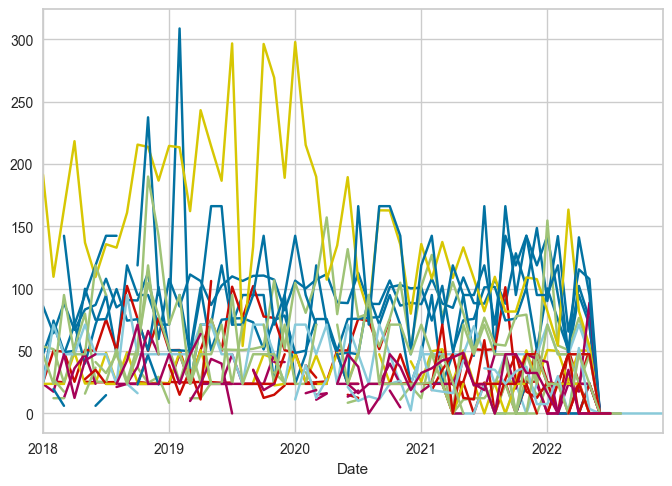

	Number of customers in cluster 1: 1


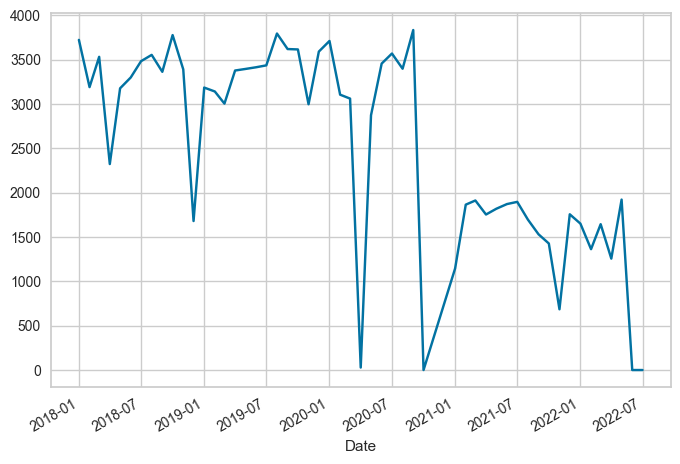

	Number of customers in cluster 2: 1


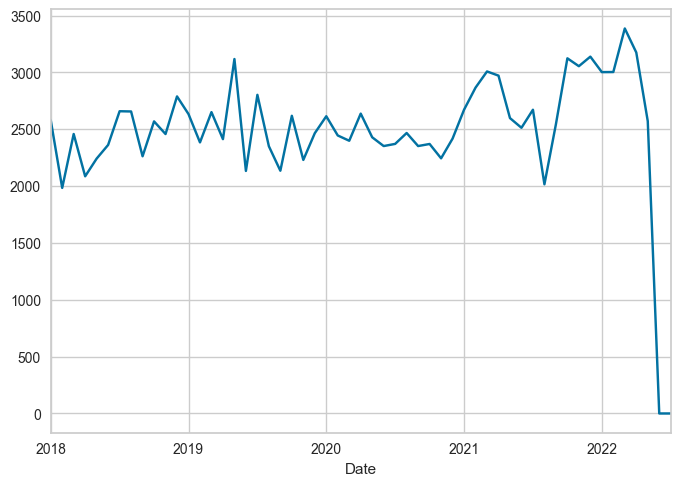

	Number of customers in cluster 4: 1


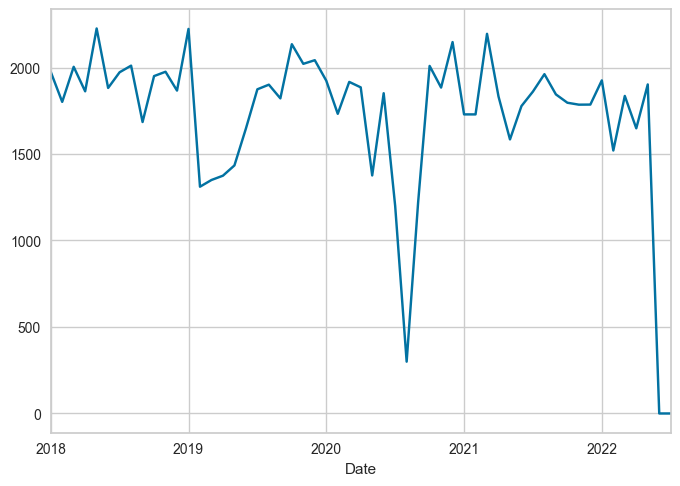

	Number of customers in cluster 3: 1


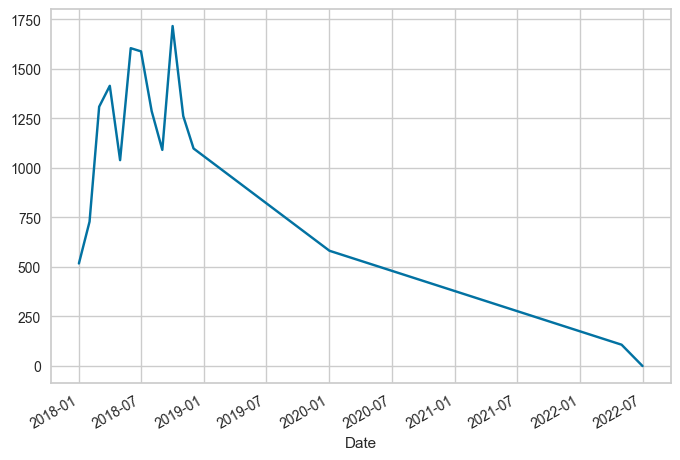

	Number of customers in cluster 5: 1


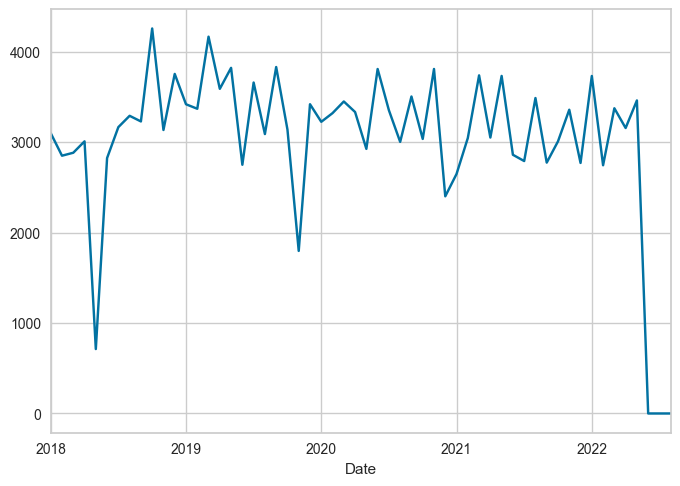

	Number of customers in cluster 10: 1


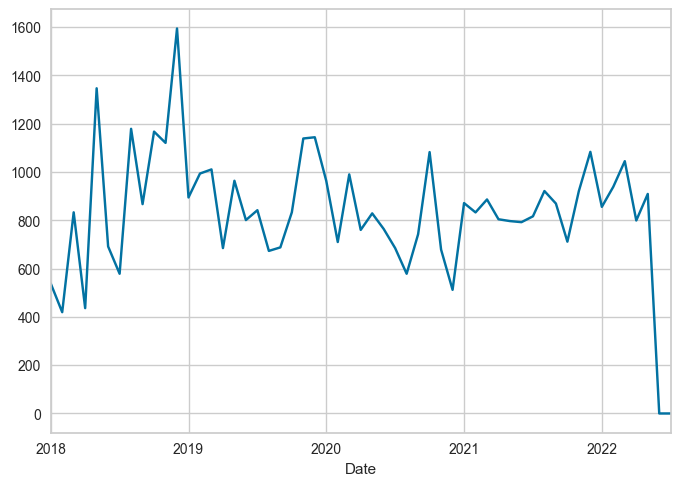

	Number of customers in cluster 11: 1


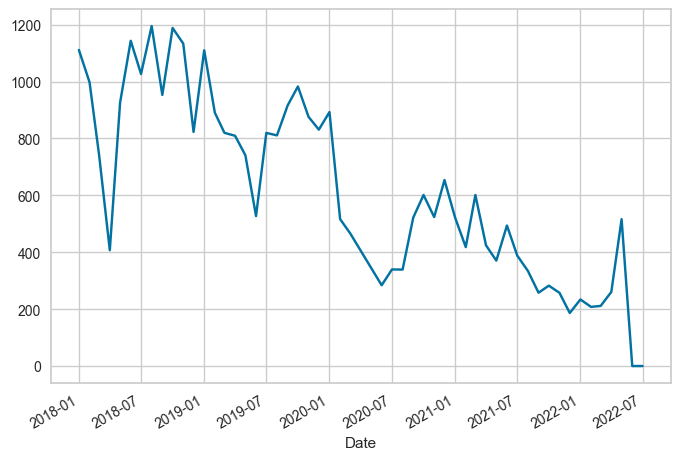

	Number of customers in cluster 8: 1


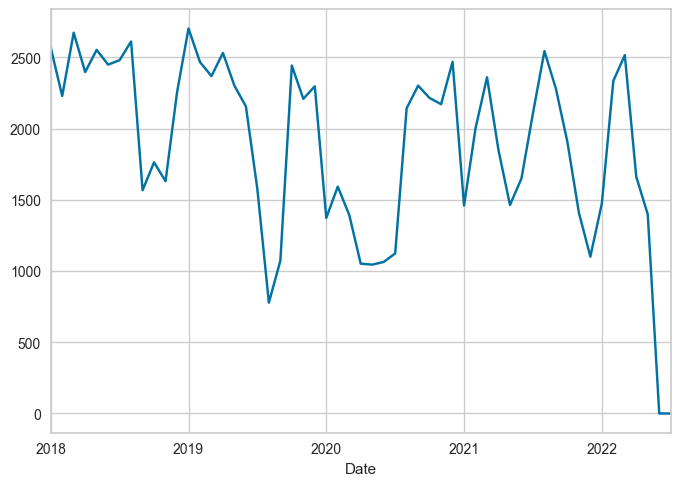

	Number of customers in cluster 7: 3


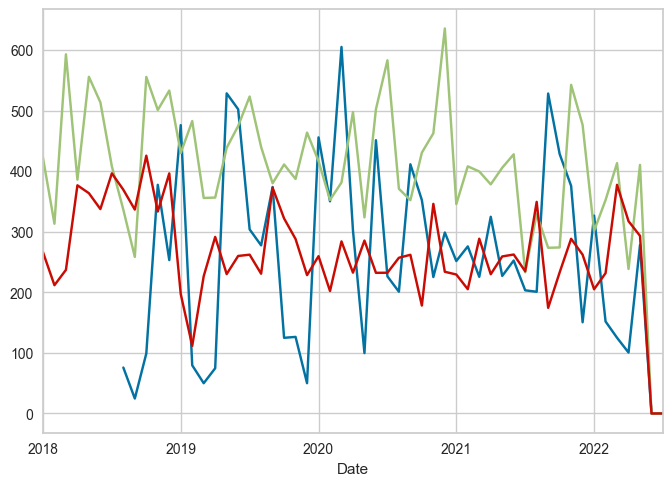

	Number of customers in cluster 9: 1


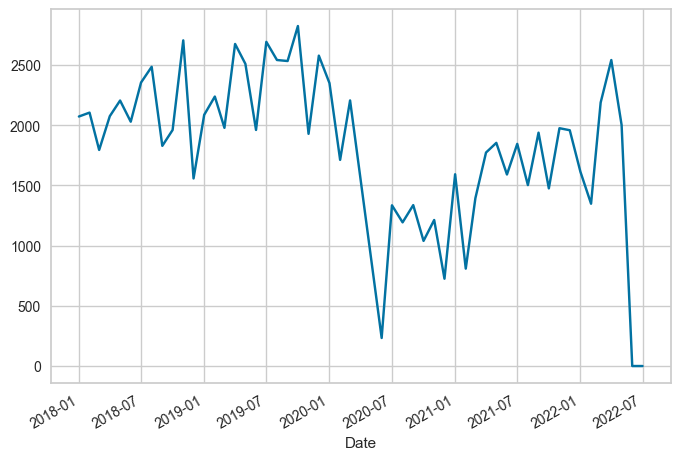

	Number of customers in cluster 6: 1


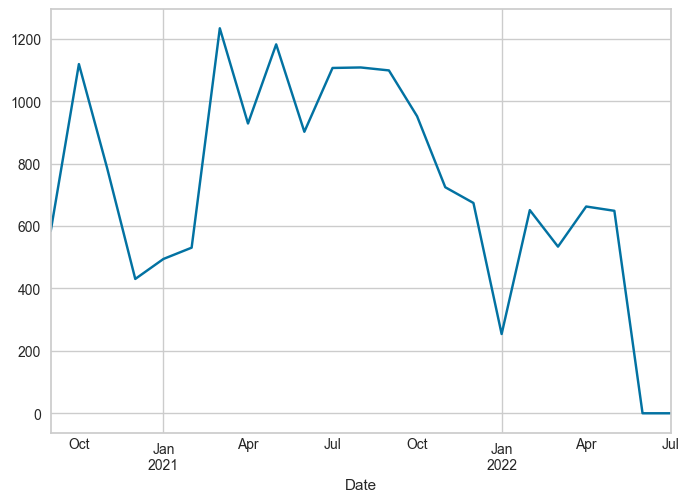

Visualizing clusters for plant: B
Number of clusters: 11
	Number of customers in cluster 0: 104


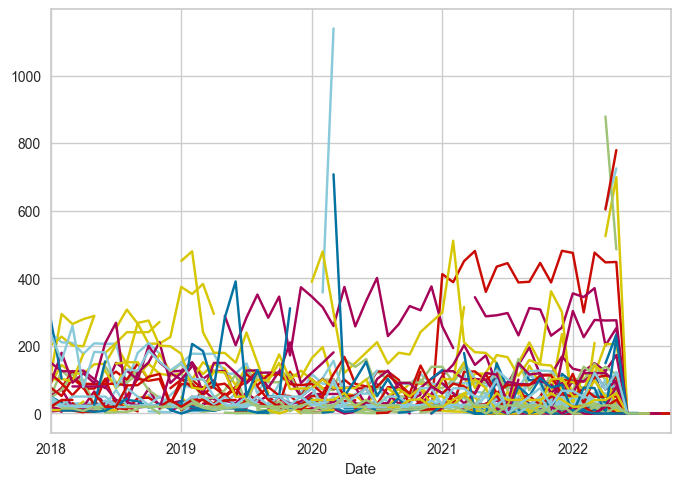

	Number of customers in cluster 4: 1


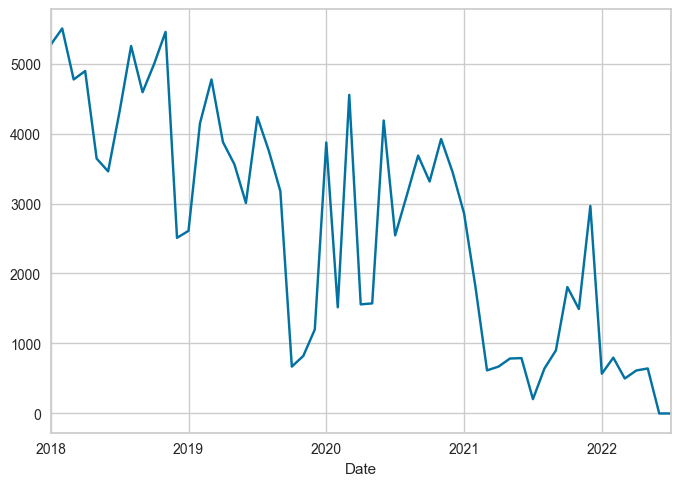

	Number of customers in cluster 7: 1


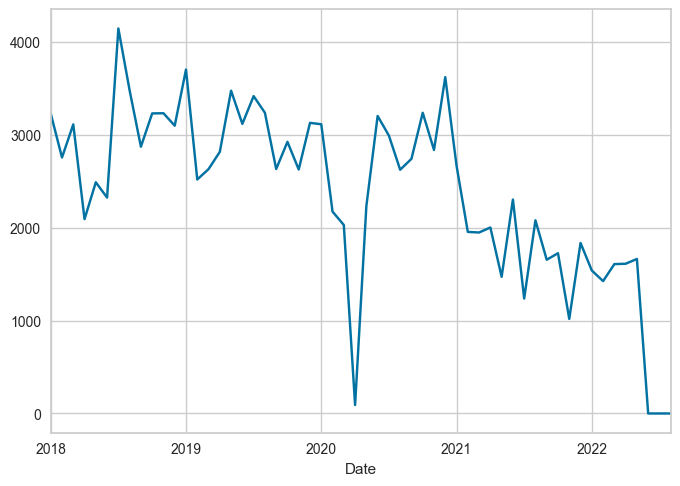

	Number of customers in cluster 9: 7


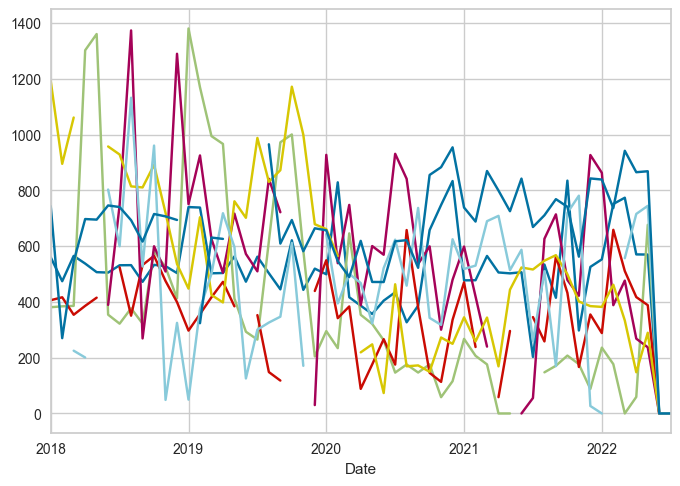

	Number of customers in cluster 8: 2


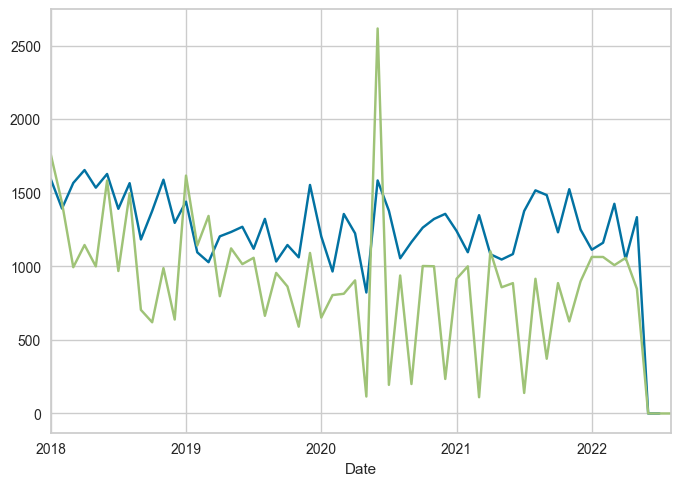

	Number of customers in cluster 2: 3


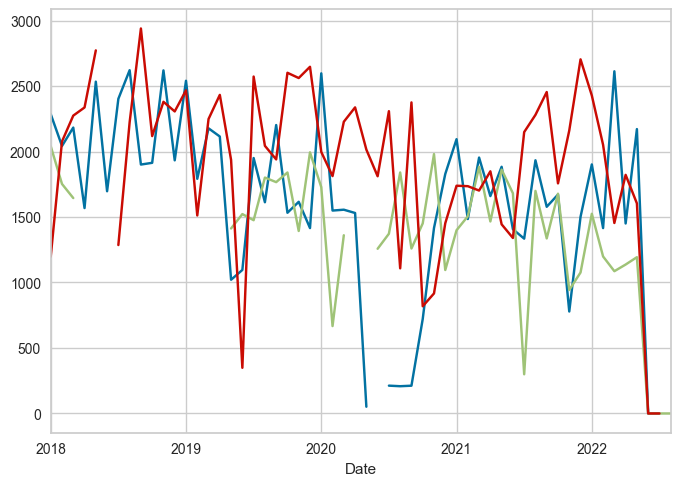

	Number of customers in cluster 1: 1


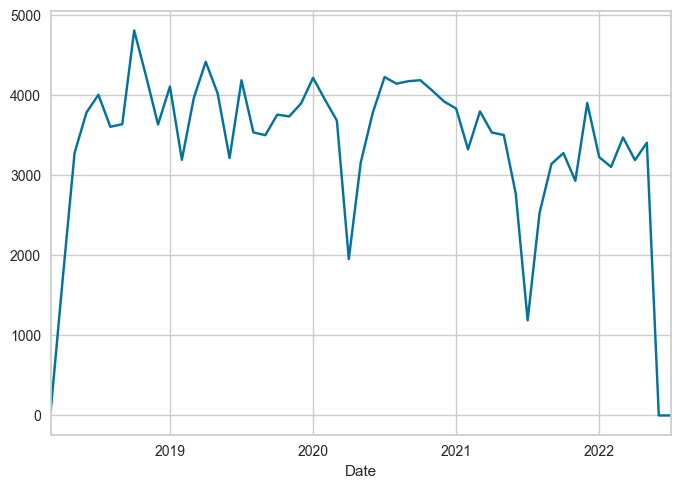

	Number of customers in cluster 6: 6


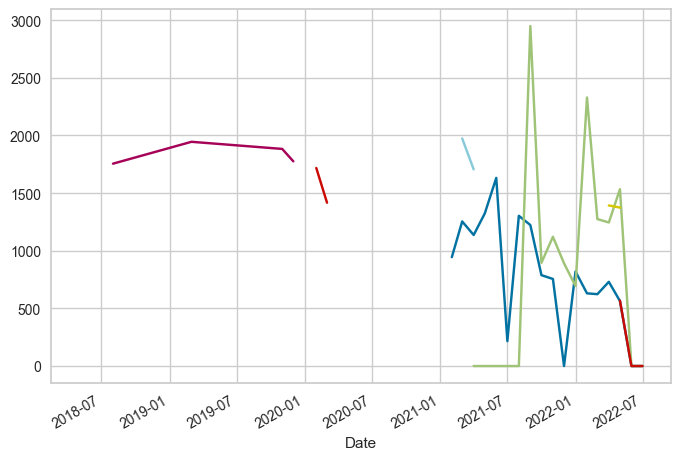

	Number of customers in cluster 5: 2


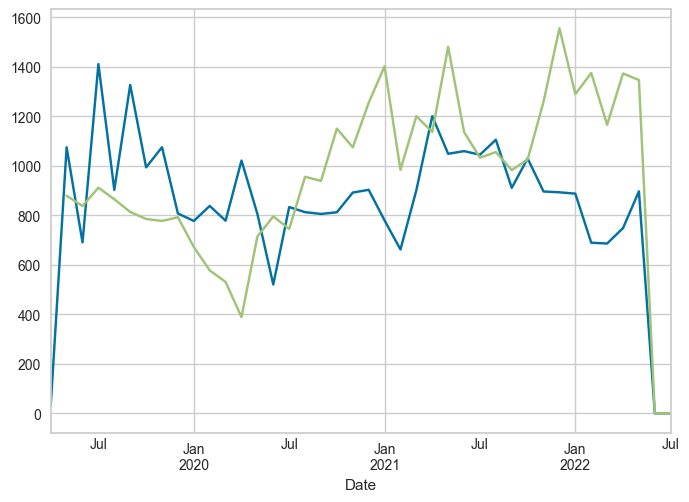

	Number of customers in cluster 10: 1


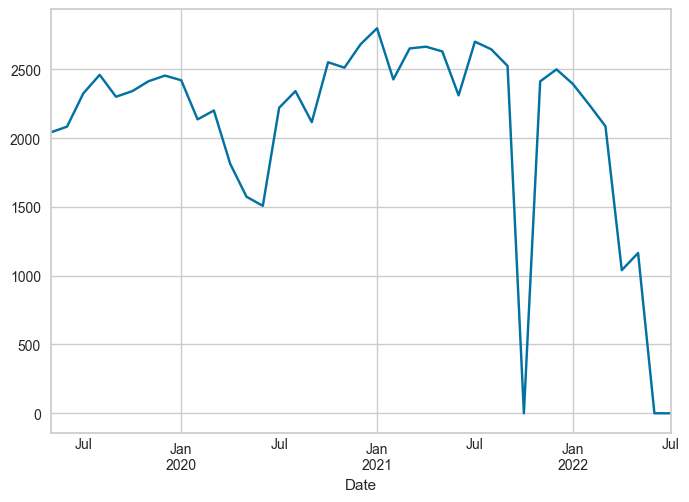

	Number of customers in cluster 3: 1


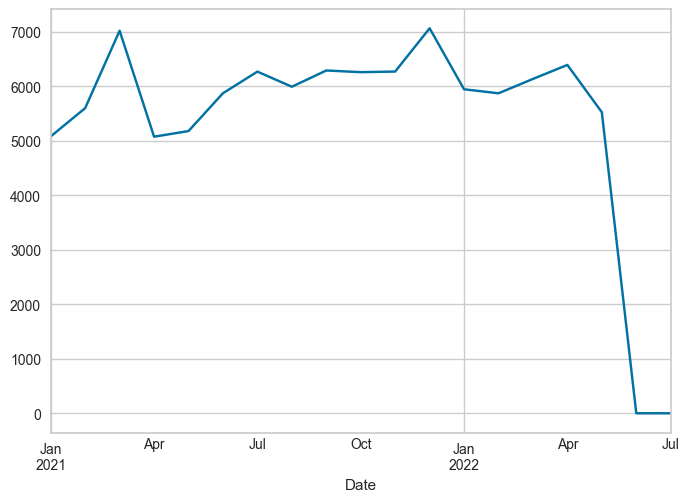

Visualizing clusters for plant: C
Number of clusters: 14
	Number of customers in cluster 0: 81


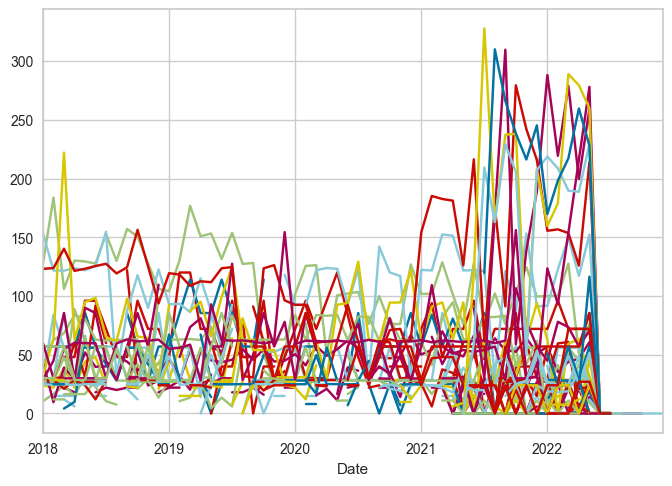

	Number of customers in cluster 11: 4


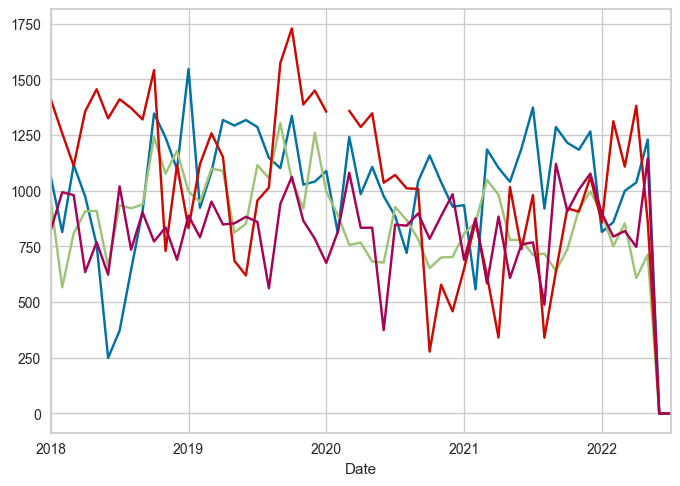

	Number of customers in cluster 1: 1


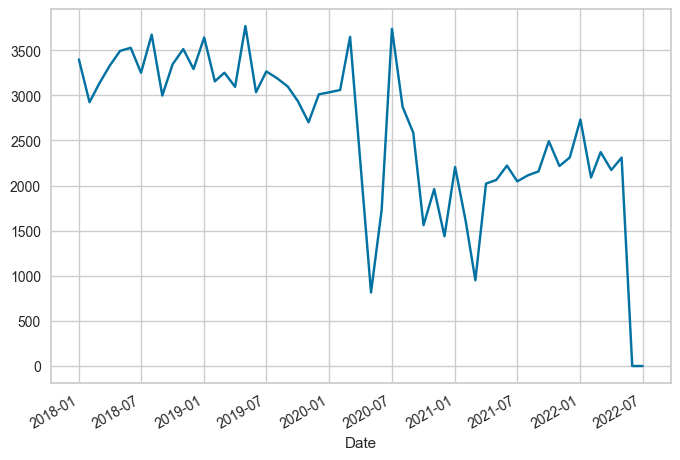

	Number of customers in cluster 7: 4


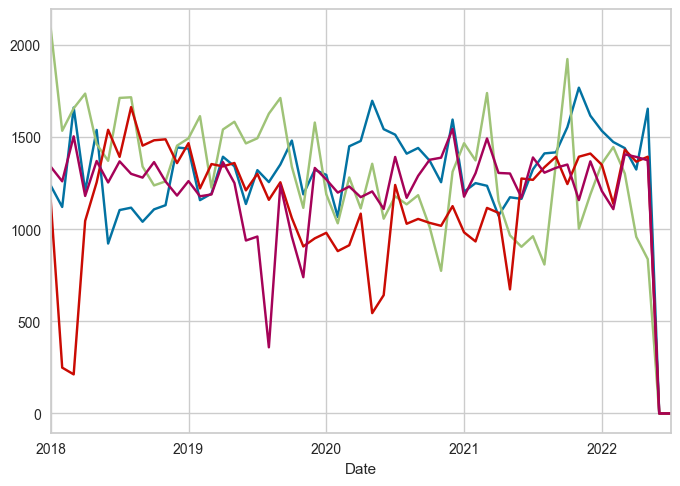

	Number of customers in cluster 10: 1


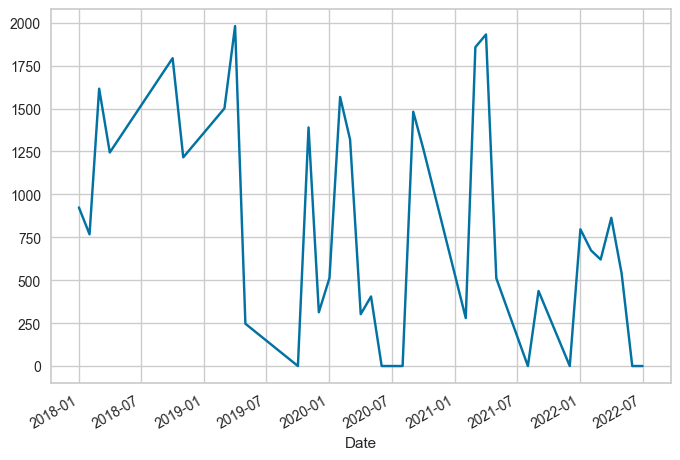

	Number of customers in cluster 6: 1


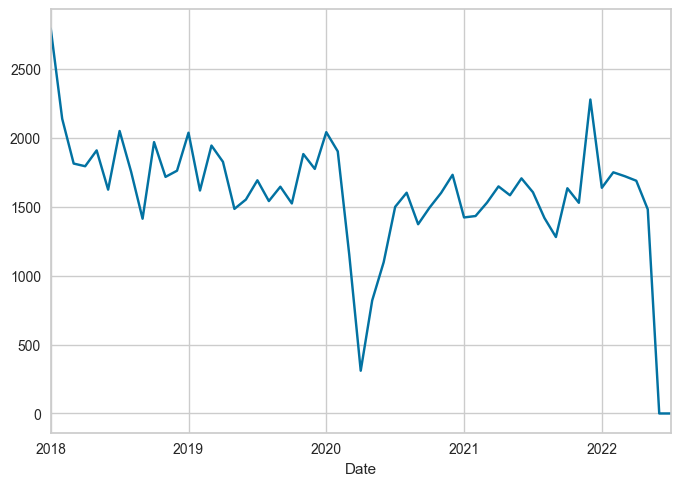

	Number of customers in cluster 9: 12


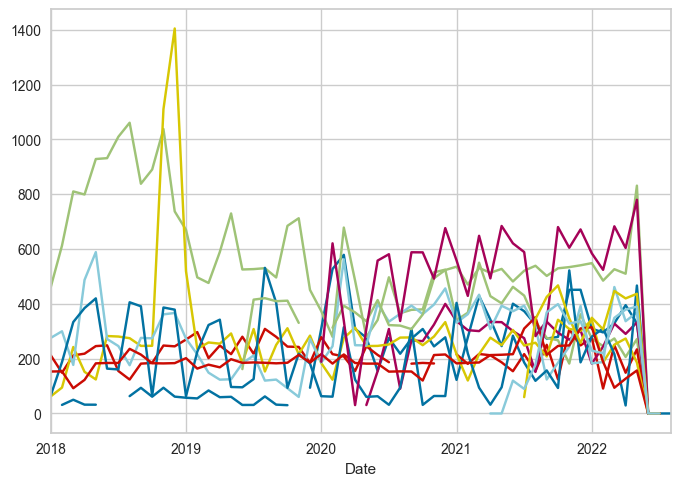

	Number of customers in cluster 4: 1


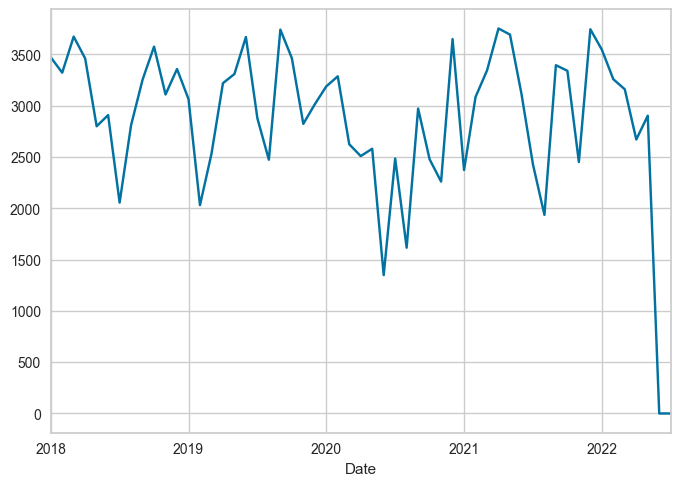

	Number of customers in cluster 5: 2


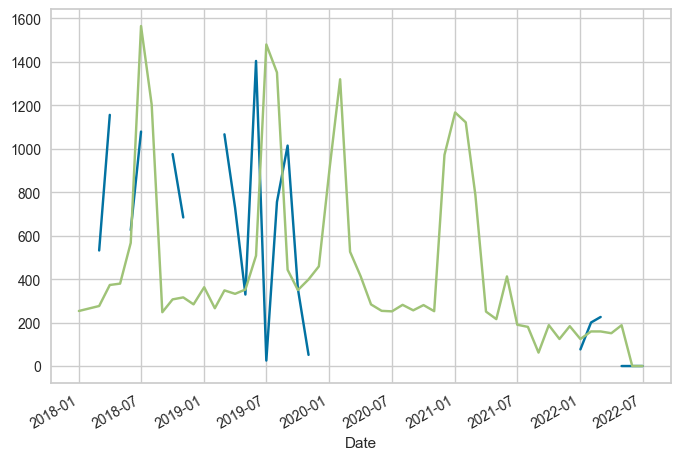

	Number of customers in cluster 3: 1


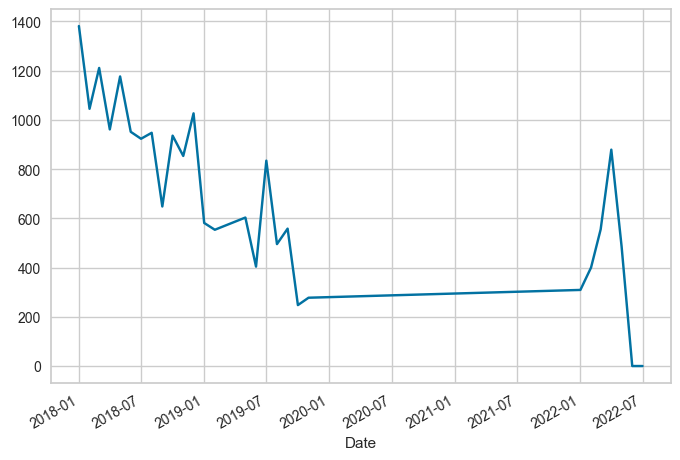

	Number of customers in cluster 12: 1


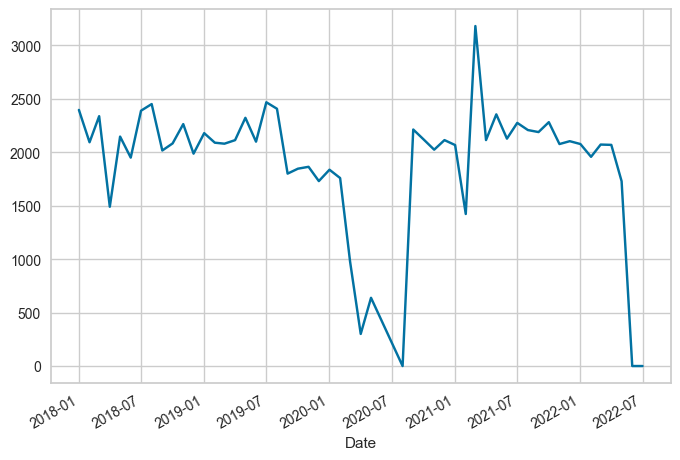

	Number of customers in cluster 2: 1


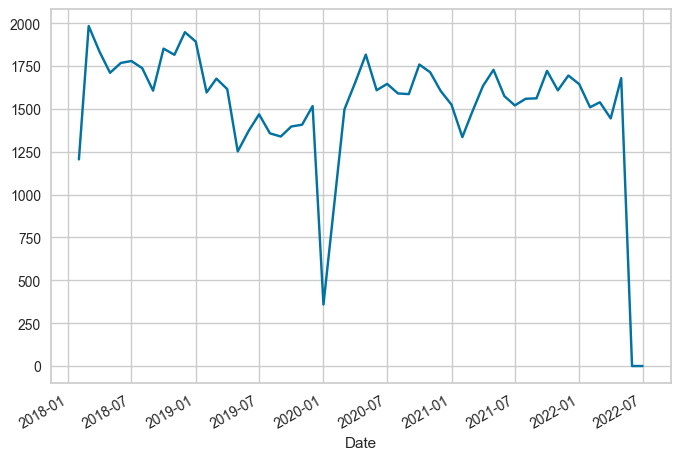

	Number of customers in cluster 8: 1


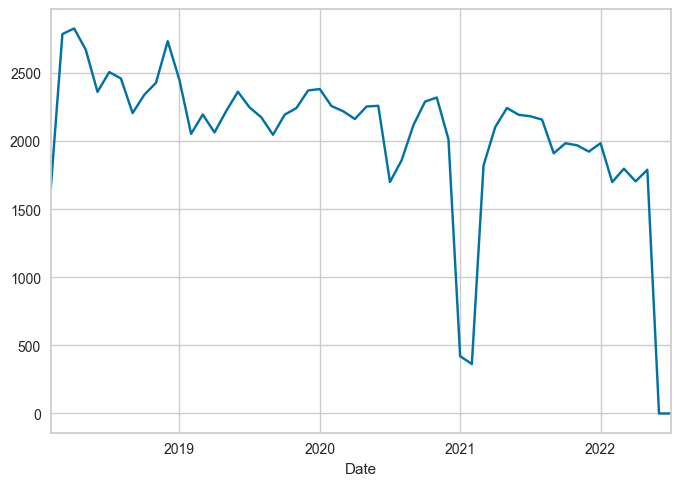

	Number of customers in cluster 13: 1


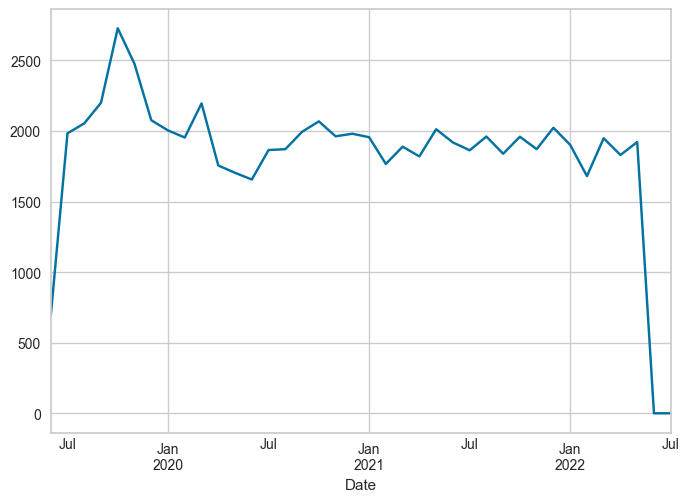

Visualizing clusters for plant: D
Number of clusters: 10
	Number of customers in cluster 4: 130


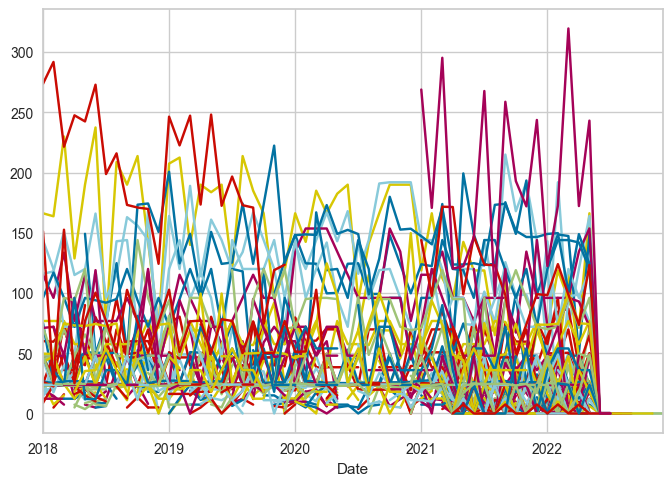

	Number of customers in cluster 0: 24


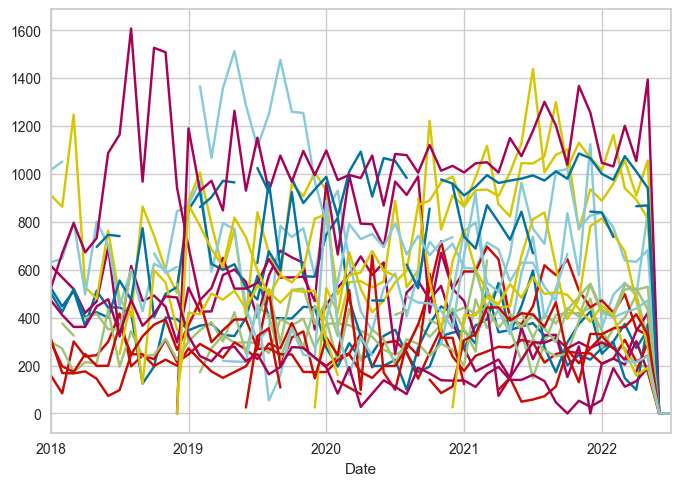

	Number of customers in cluster 5: 1


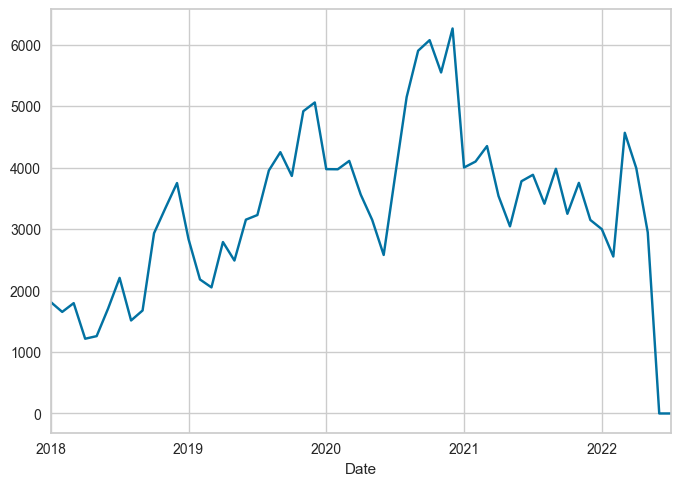

	Number of customers in cluster 8: 1


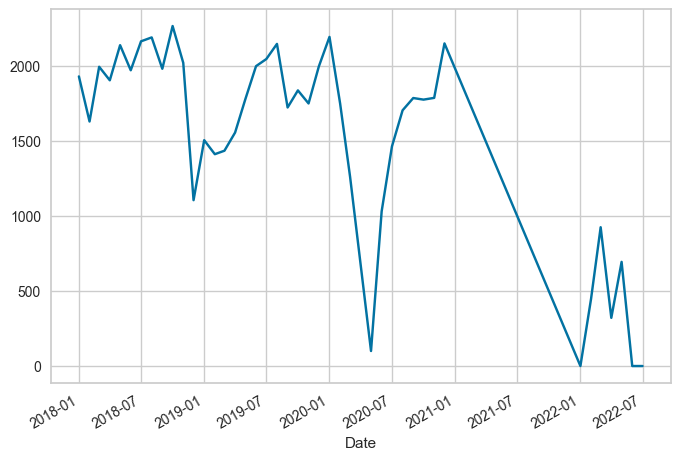

	Number of customers in cluster 1: 1


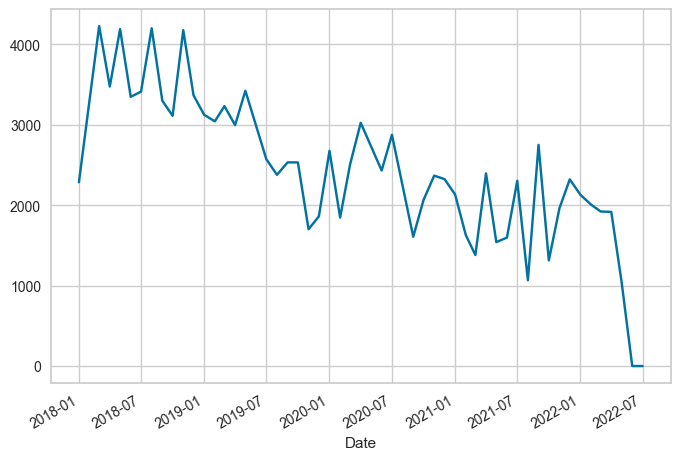

	Number of customers in cluster 6: 1


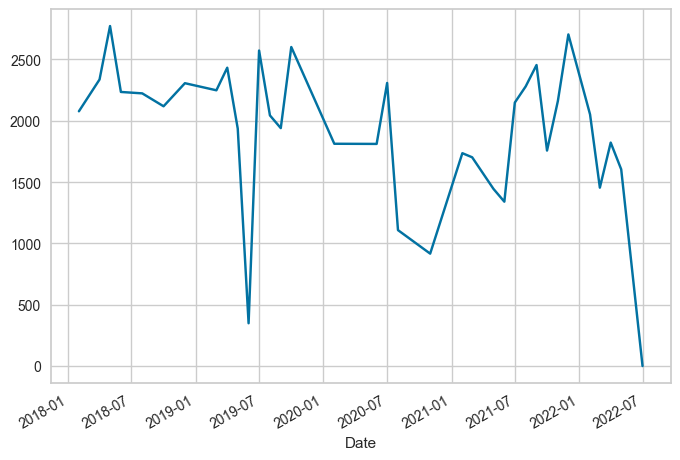

	Number of customers in cluster 2: 1


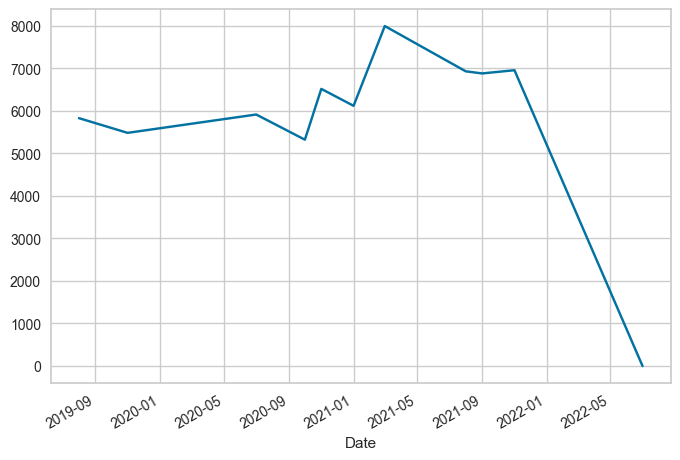

	Number of customers in cluster 9: 1


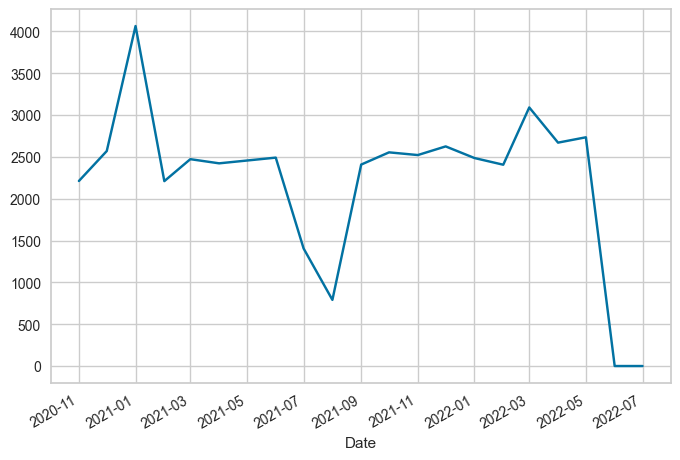

	Number of customers in cluster 7: 1


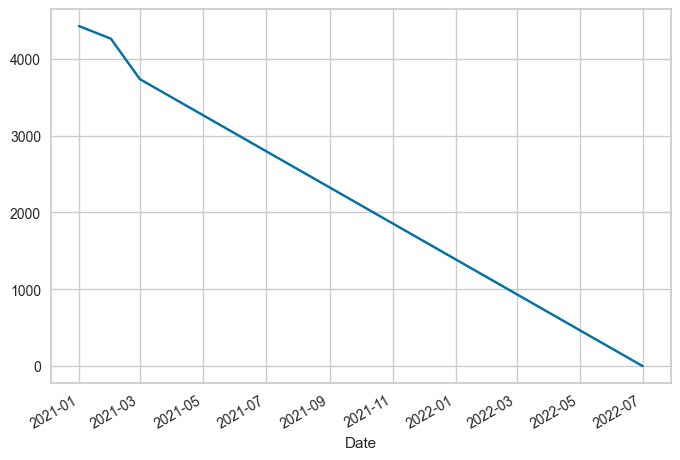

	Number of customers in cluster 3: 1


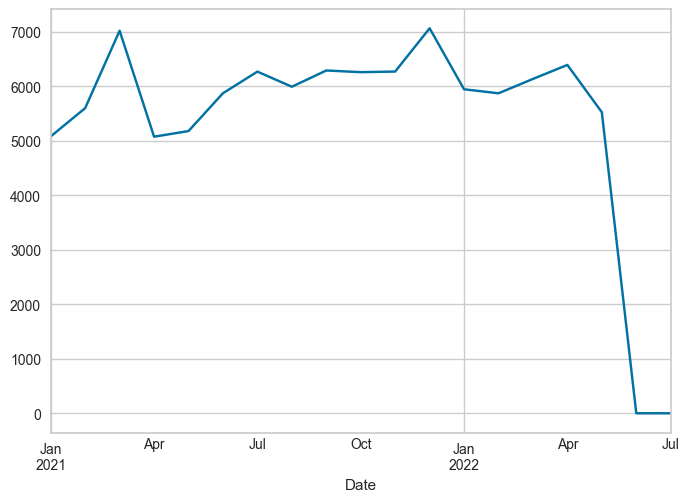

Visualizing clusters for plant: E
Number of clusters: 8
	Number of customers in cluster 0: 43


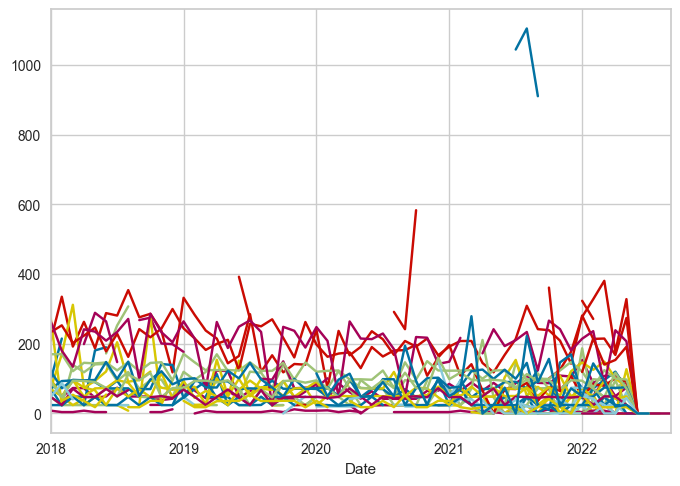

	Number of customers in cluster 4: 6


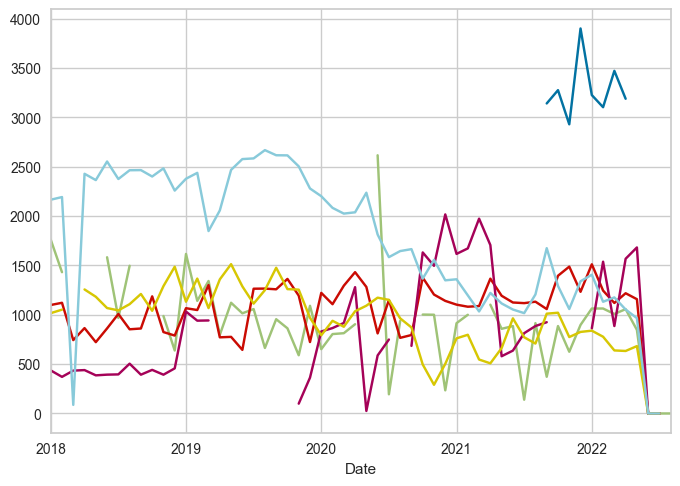

	Number of customers in cluster 7: 19


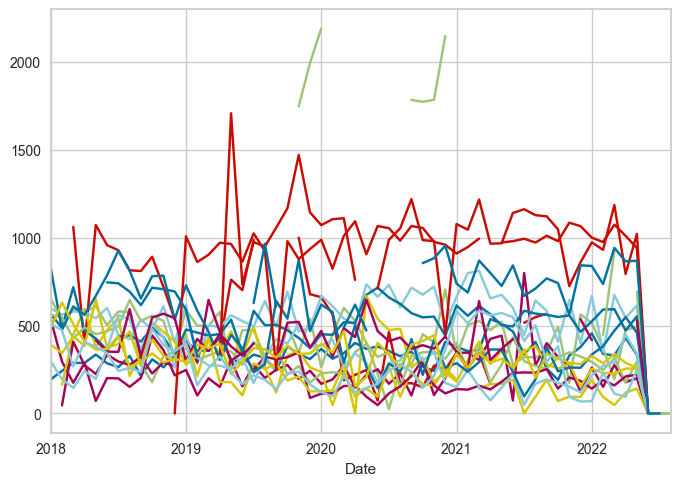

	Number of customers in cluster 2: 2


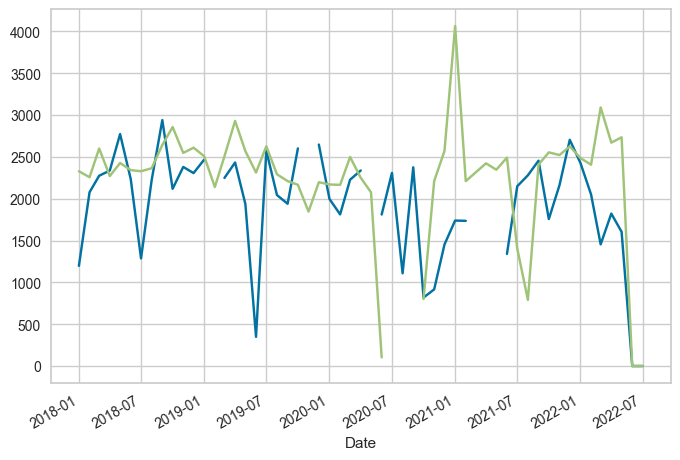

	Number of customers in cluster 1: 1


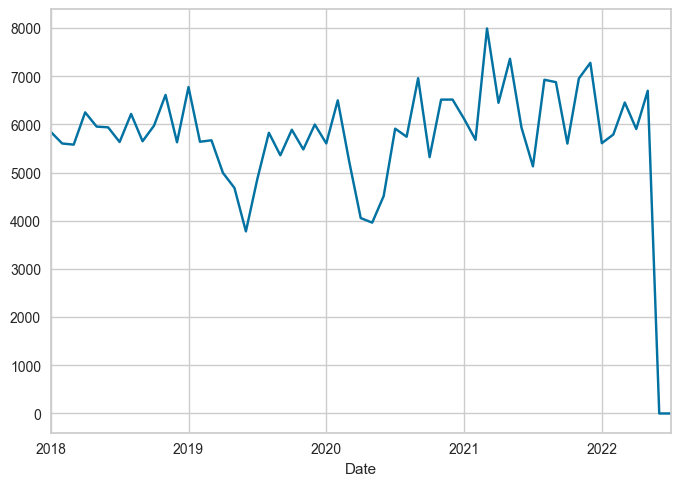

	Number of customers in cluster 6: 1


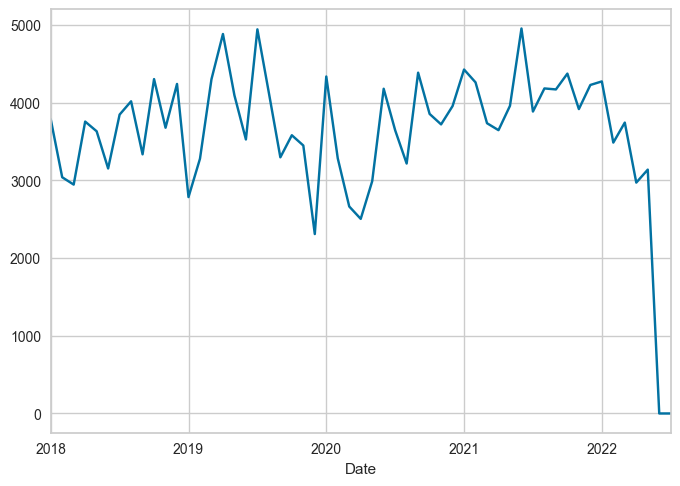

	Number of customers in cluster 5: 1


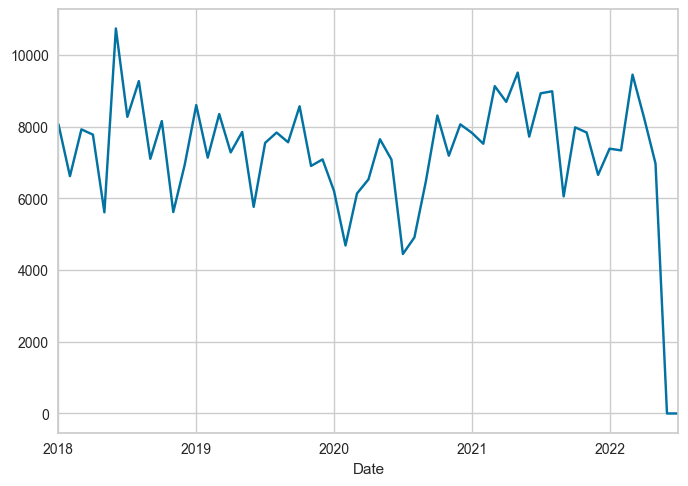

	Number of customers in cluster 3: 1


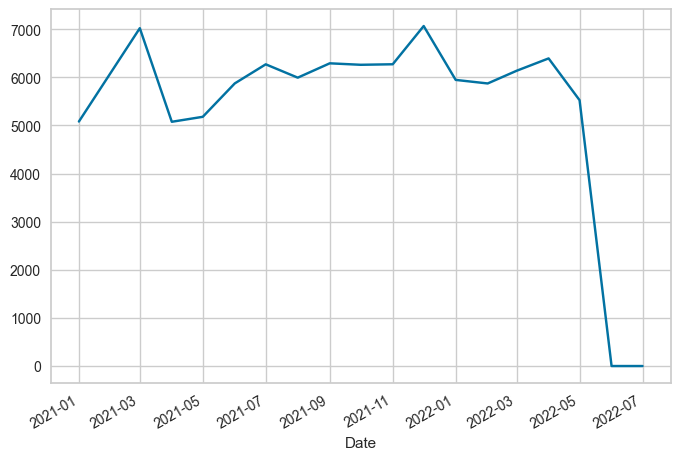

Visualizing clusters for plant: F
Number of clusters: 4
	Number of customers in cluster 0: 53


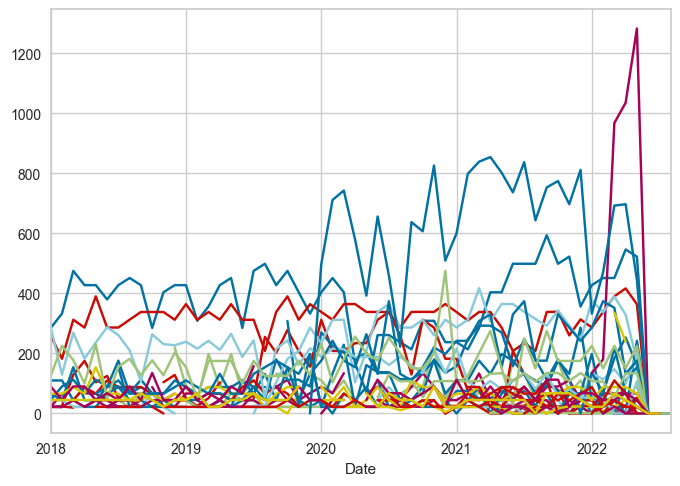

	Number of customers in cluster 2: 6


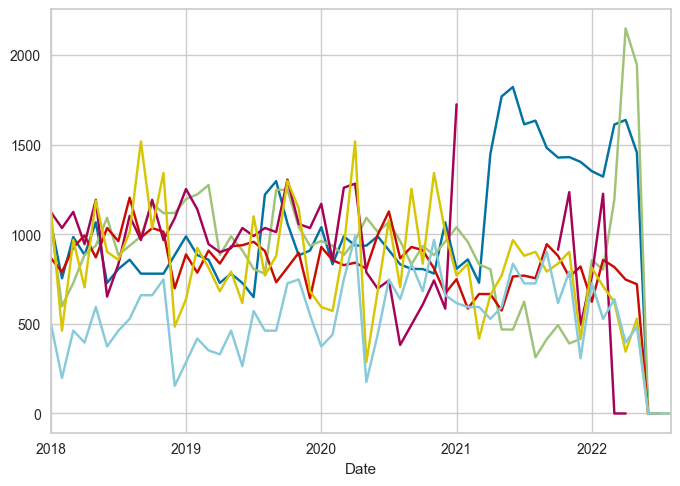

	Number of customers in cluster 1: 1


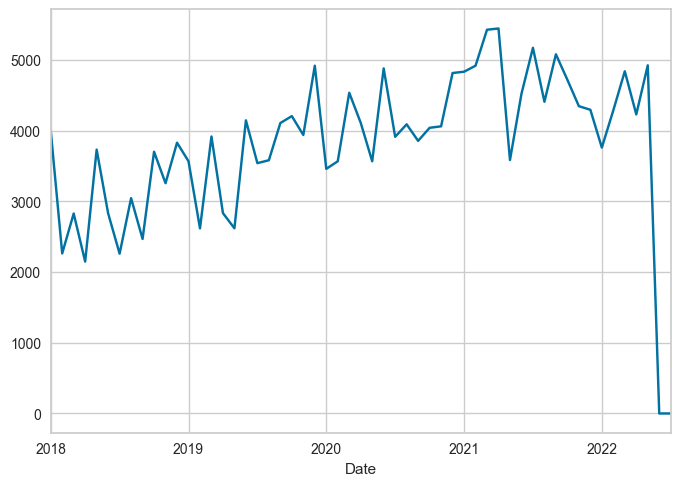

	Number of customers in cluster 3: 1


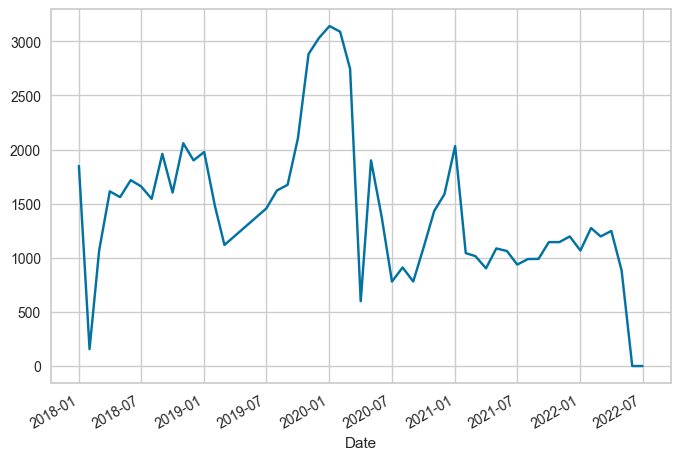

In [52]:
for i in kms.keys():
    viz_plant(i)

In [53]:
labelled1 = {i:j[j.customer_id.isin(j.query("Date<'01-01-2021'").groupby('customer_id')[0].sum().to_frame().rename({0:'value'}, axis=1).query('value>0').index)] for i,j in labelled.items()}

In [57]:
dict(map(lambda x: (x[0], x[1].customer_id.nunique()), labelled1.items()))

{'A': 44, 'B': 109, 'C': 101, 'D': 151, 'E': 67, 'F': 53}

In [58]:
plant_level1 = pd.concat((j.reset_index().groupby('Date')[0].sum().to_frame().rename({0:i}, axis=1) for i,j in labelled1.items()), axis=1)

In [59]:
total_level1 = plant_level1.sum(axis=1).to_frame().rename({0:'total'}, axis=1)
label_level1 = pd.concat((j.reset_index().groupby(['Date', 'label'])[0].sum().unstack(1).rename({k:f'{i}_{k}' for k in j.label.unique()}, axis=1) for i,j in labelled1.items()), axis=1)

In [61]:
customer_level1 = pd.concat((i.reset_index().groupby(['Date', 'customer_id'])[0].sum().unstack() for i in labelled1.values()), axis=1)

In [63]:
customer_level1.columns = customer_level1.columns.map(str)

In [64]:
hierarchy_df = customer_level1.join(label_level1) \
                              .join(plant_level1).join(total_level1)
hierarchy_df.index = pd.to_datetime(hierarchy_df.index)
hierarchy_df = hierarchy_df.resample('MS').sum()

print(f'Number of customers at the top level: {total_level1.shape[1]}')
print(f'Number of customers at the first level: {plant_level1.shape[1]}')
print(f'Number of customers at the second level: {label_level1.shape[1]}')
print(f'Number of customers at the third level: {customer_level1.shape[1]}')

Number of customers at the top level: 1
Number of customers at the first level: 6
Number of customers at the second level: 55
Number of customers at the third level: 525


# No train data filter

In [69]:
bl = customer_level1[customer_level1.index<'01-01-2021']

In [70]:
bl = bl.T[bl.sum()!=0].T

In [72]:
sl = label_level1[label_level1.index<'01-01-2021']
sl = sl.T[sl.sum()!=0].T

In [73]:
fl = plant_level1[plant_level1.index<'01-01-2021']
fl = fl.T[fl.sum()!=0].T

In [74]:
hdf = bl.join(sl).join(fl).join(total_level1)
hdf.index = pd.to_datetime(hdf.index)
hdf = hdf.resample('MS').sum()

print(f'Number of customers at the top level: {total_level1.shape[1]}')
print(f'Number of customers at the first level: {plant_level1.shape[1]}')
print(f'Number of customers at the second level: {label_level1.shape[1]}')
print(f'Number of customers at the third level: {customer_level1.shape[1]}')

Number of customers at the top level: 1
Number of customers at the first level: 6
Number of customers at the second level: 55
Number of customers at the third level: 525


In [75]:
total = {'total':list(lsdf.keys())}

In [77]:
plants = pd.DataFrame(sl.columns.str.split('_').tolist()).groupby(0)[1].unique().map(list).reset_index().set_index(0, drop=False).apply(lambda x: [f'{x[0]}_{i}' for i in x[1]], axis=1).to_dict()

In [79]:
def format_label_plants(x: pd.DataFrame, j:str)->pd.Series:
    x = x[['customer_id', 'label']].drop_duplicates().groupby('label').customer_id.unique()
    x.index = [f'{j}_{i}' for i in x.index]
    x = x.map(list)
    return x

In [80]:
label = pd.concat([format_label_plants(j,i) for i,j in labelled1.items()]).to_dict()

In [81]:
hierarchy = {**total, **plants, **label}

In [82]:
hierarchy = {i:[str(k) for k in j] for i,j in hierarchy.items()}

In [83]:
%matplotlib inline

<Axes: title={'center': 'Invoces - total level'}, xlabel='Date'>

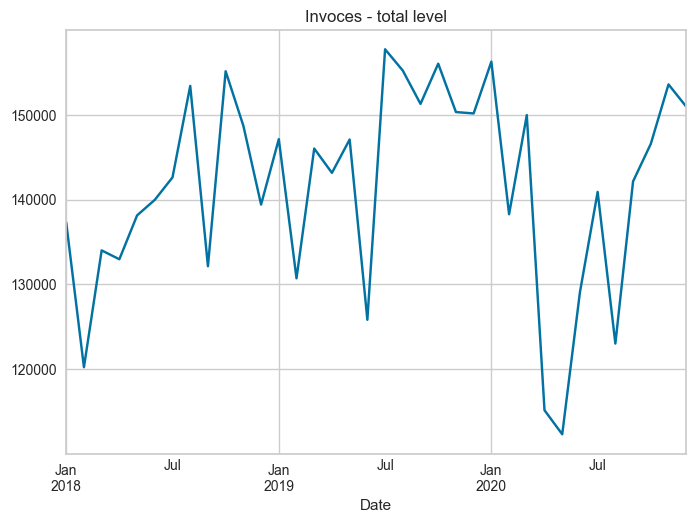

In [84]:
hdf['total'].plot(title = 'Invoces - total level')

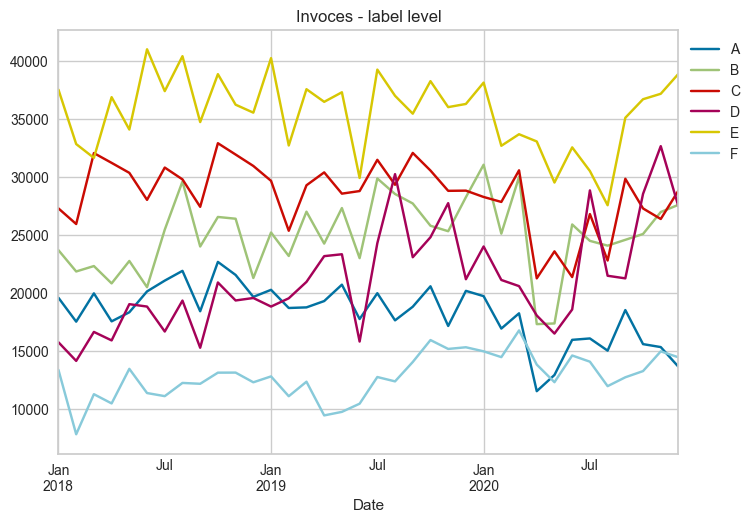

In [85]:
ax = hdf[hierarchy['total']].plot(title = 'Invoces - label level')
ax.legend(bbox_to_anchor=(1,1))

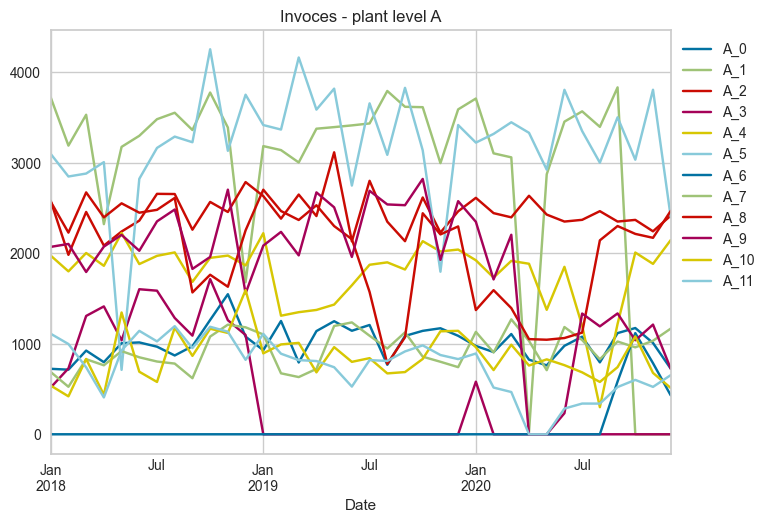

In [87]:
ax = hdf[hierarchy['A']].plot(title = 'Invoces - plant level A')
ax.legend(bbox_to_anchor=(1,1))

In [88]:
hdf = hdf.T[hdf.sum()!=0].T

In [89]:
keys = hierarchy.keys()

for plant in hierarchy['total']:
    hierarchy[plant] = [i for i in hierarchy[plant] if i in keys]

In [90]:
ddd = dict()

foo = [j for i in hierarchy['total'] for j in hierarchy[i]]
for i in foo:
    print(i, hierarchy[i])
    zz = []
    for v in hierarchy[i]:
        zz.append(i + '_' + v)
        ddd[v] = i + '_' + v
    hierarchy[i] = zz

A_0 ['4', '37', '47', '52', '56', '63', '75', '79', '103', '107', '115', '130', '131', '8', '16', '43', '102', '790', '792', '793', '74', '50', '101', '67', '119', '55', '794', '789', '787', '137', '7']
A_1 ['29']
A_2 ['30']
A_3 ['32']
A_4 ['31']
A_5 ['35']
A_6 ['53']
A_7 ['117', '118', '49']
A_8 ['82']
A_9 ['932']
A_10 ['54']
A_11 ['70']
B_0 ['147', '148', '158', '163', '165', '169', '171', '174', '203', '209', '210', '216', '230', '231', '236', '240', '257', '268', '269', '294', '295', '297', '780', '783', '784', '833', '846', '851', '854', '856', '857', '858', '867', '872', '873', '880', '897', '900', '905', '978', '981', '1101', '146', '172', '188', '202', '214', '227', '881', '882', '161', '170', '173', '229', '246', '652', '756', '769', '198', '839', '883', '175', '212', '254', '770', '293', '1147', '242', '860', '149', '834', '142', '141', '144', '271', '154', '270', '906', '843', '251', '838', '1049', '192', '250', '197', '266', '205']
B_1 ['215']
B_2 ['200', '218', '893']
B_4 

In [91]:
hdf.columns = [i if i not in ddd else ddd[i] for i in hdf.columns]
hierarchy_df.columns = [i if i not in ddd else ddd[i] for i in hierarchy_df.columns]

In [97]:
h_df.Date

0    2018-01-01
1    2018-02-01
2    2018-03-01
3    2018-04-01
4    2018-05-01
5    2018-06-01
6    2018-07-01
7    2018-08-01
8    2018-09-01
9    2018-10-01
10   2018-11-01
11   2018-12-01
12   2019-01-01
13   2019-02-01
14   2019-03-01
15   2019-04-01
16   2019-05-01
17   2019-06-01
18   2019-07-01
19   2019-08-01
20   2019-09-01
21   2019-10-01
22   2019-11-01
23   2019-12-01
24   2020-01-01
25   2020-02-01
26   2020-03-01
27   2020-04-01
28   2020-05-01
29   2020-06-01
30   2020-07-01
31   2020-08-01
32   2020-09-01
33   2020-10-01
34   2020-11-01
35   2020-12-01
Name: Date, dtype: datetime64[ns]

In [99]:
# split into train and test
h_df = hdf.reset_index()
df_train = h_df[h_df.Date<'01-01-2021'].copy()
h_df = hierarchy_df.reset_index()
df_test = h_df[(h_df.Date>='01-01-2021')&(h_df.Date<='06-01-2022')].copy()

<Axes: xlabel='Date'>

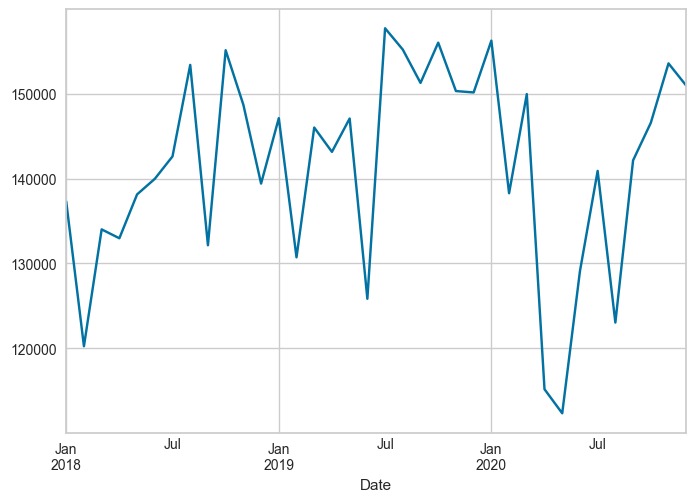

In [102]:
df_train.set_index("Date").total.plot()

In [107]:
df_train = df_train.set_index('Date').T[df_train.set_index('Date').sum()!=0].T.reset_index()
df_test = df_test.loc[:, df_train.columns]

In [121]:
df_train.to_csv('../../data/processed/hierarchy_train.csv', index=False)
df_test.to_csv('../../data/processed/hierarchy_test.csv', index=False)

In [ ]:
def rolling_orders_6(x):
    """Check if average non-zero invoices in rolling windows exceeds threshold"""
    ts = x.set_index('Date').sort_index().Invoiced_Quantity
    # More efficient way to count non-zero values in each window
    return ts.rolling(6).apply(lambda x: (x > 0).sum()).mean() > 2






/var/folders/tj/c9x9f0j55b53skv8htzftqsh0000gn/T/ipykernel_25772/1337255762.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.query('Plant=="A"').groupby('customer_id').apply(rolling_orders_6)


customer_id
0       True
1      False
2      False
3       True
4       True
       ...  
934     True
935     True
936     True
938     True
939     True
Length: 198, dtype: bool